# ABCNG Ablation Runner
This notebook runs ablation variants and saves results into per-variant folders under `figs/ablation_runs/`.


## Setup and Suite


Defines the benchmark functions, dimensions, and evaluation budget used across all runs.


## Settings (edit here)

- `functions`: benchmarks to run
- `dims`: dimensions to test
- `budget`: evaluation budget per function & dim
- `runs`: number of independent runs (seeds)
- `pop_size`: population size (SN)

**Note on `paper_mode`:**
ABCNG variants are run with `paper_mode=True`, which enforces SN=50, limit=SN·D, max_evals=5000·D, and the onlooker visit-each-source behavior.


In [1]:
from tools.ablation import run_ablation_suite

functions = ["sphere", "rastrigin", "rosenbrock", "ackley", "griewank", "schwefel"]
dims = [30, 50, 100]
suite = [(fn, d, 5000 * d) for fn in functions for d in dims]

base_out = "figs/ablation_runs"


## Variants


Lists the algorithm variants (component removals and alternatives) that will be evaluated.


In [2]:
variants = [
    ("abc", "abc", None),
    ("abcng_full", "abcng", {}),
    ("no_gbest", "abcng", {"use_gbest": False}),
    ("no_adaptive_k", "abcng", {"use_adaptive_k": False}),
    ("no_gaussian", "abcng", {"use_gaussian": False}),
    ("self_in_eq7", "abcng", {"neighbor_mode": "self"}),
    ("single_dim_update", "abcng", {"update_dim_mode": "single"}),
    ("k_random_dim_update", "abcng", {"update_dim_mode": "k_random", "update_dim_k": 5}),
    ("noise_cauchy", "abcng", {"noise_model": "cauchy"}),
    ("noise_uniform", "abcng", {"noise_model": "uniform"}),
    ("no_gbest_no_adaptive_k", "abcng", {"use_gbest": False, "use_adaptive_k": False}),
    ("no_gbest_no_gaussian", "abcng", {"use_gbest": False, "use_gaussian": False}),
    ("no_adaptive_k_no_gaussian", "abcng", {"use_adaptive_k": False, "use_gaussian": False}),
    ("no_gbest_no_adaptive_k_no_gaussian", "abcng", {"use_gbest": False, "use_adaptive_k": False, "use_gaussian": False}),
    ("self_in_eq7_no_gbest", "abcng", {"neighbor_mode": "self", "use_gbest": False}),
    ("self_in_eq7_no_gaussian", "abcng", {"neighbor_mode": "self", "use_gaussian": False}),
]


## Run Ablations


Runs each variant, saves CSVs and plots into per-variant subfolders under `figs/ablation_runs/`.


## Rerun behavior

Set `FORCE_RERUN=True` to overwrite existing results for a variant.
If `runs.csv` already exists and `FORCE_RERUN=False`, the variant is skipped.


In [3]:
import os

FORCE_RERUN = False  # set True to retrain and overwrite results

for name, algo, kwargs in variants:
    print("Running", name)
    out_dir = f"{base_out}/{name}"
    runs_path = os.path.join(out_dir, "runs.csv")
    if os.path.exists(runs_path) and not FORCE_RERUN:
        print(f"Skipping {name}, results already exist: {runs_path}")
        continue
    v = [{"name": name, "algo": algo, "abcng_kwargs": kwargs or {}}]
    if algo == "abcng":
        v[0]["abcng_kwargs"] = {"paper_mode": True, **(kwargs or {})}
    df, _ = run_ablation_suite(
        suite,
        variants=v,
        runs=25,
        pop_size=50,
        out_dir=out_dir,
    )
    display(df.head())
    print("Saved ->", out_dir)


Running abc


,function,dim,budget,runs,variant,median_final,mean_final,std_final,median_time_s
0,sphere,30,150000,25,abc,5.224078e-09,6.023581e-09,2.718461e-09,2.744450
1,sphere,50,250000,25,abc,9.757788e-02,1.065872e-01,4.739430e-02,4.328716
2,sphere,100,500000,25,abc,1.273567e+04,1.262145e+04,1.192861e+03,8.768877
3,rastrigin,30,150000,25,abc,1.813919e+02,1.766061e+02,1.855975e+01,2.821368
4,rastrigin,50,250000,25,abc,3.976221e+02,3.919119e+02,4.087696e+01,4.721605


Saved -> figs/ablation_runs/abc
Running abcng_full


,function,dim,budget,runs,variant,median_final,mean_final,std_final,median_time_s
0,sphere,30,150000,25,abcng_full,1.584100e-170,5.193214e-166,0.000000e+00,2.530773
1,sphere,50,250000,25,abcng_full,3.898946e-138,7.625414e-134,3.726005e-133,4.188537
2,sphere,100,500000,25,abcng_full,2.652325e-87,3.883487e-84,1.279254e-83,8.393798
3,rastrigin,30,150000,25,abcng_full,9.054089e+01,9.002348e+01,2.667081e+01,1.988318
4,rastrigin,50,250000,25,abcng_full,2.328190e+02,2.297546e+02,3.804918e+01,3.702624


Saved -> figs/ablation_runs/abcng_full
Running no_gbest


...

Saved -> figs/ablation_runs/no_gbest_no_adaptive_k_no_gaussian
Running self_in_eq7_no_gbest


,function,dim,budget,runs,variant,median_final,mean_final,std_final,median_time_s
0,sphere,30,150000,25,self_in_eq7_no_gbest,0.000051,0.000051,0.000020,1.312533
1,sphere,50,250000,25,self_in_eq7_no_gbest,6.248576,6.519012,1.484336,2.204119
2,sphere,100,500000,25,self_in_eq7_no_gbest,23052.391022,22555.126847,2152.839013,4.482808
3,rastrigin,30,150000,25,self_in_eq7_no_gbest,200.456381,197.885894,13.740698,1.493064
4,rastrigin,50,250000,25,self_in_eq7_no_gbest,427.434013,422.105278,28.144490,2.515529


Saved -> figs/ablation_runs/self_in_eq7_no_gbest
Running self_in_eq7_no_gaussian


,function,dim,budget,runs,variant,median_final,mean_final,std_final,median_time_s
0,sphere,30,150000,25,self_in_eq7_no_gaussian,1.082357e-130,9.881455e-130,1.552159e-129,1.674131
1,sphere,50,250000,25,self_in_eq7_no_gaussian,3.117340e-112,5.593687e-110,1.819461e-109,2.780961
2,sphere,100,500000,25,self_in_eq7_no_gaussian,4.706930e-79,1.883812e-77,7.784824e-77,5.742062
3,rastrigin,30,150000,25,self_in_eq7_no_gaussian,5.472245e+01,5.352861e+01,1.526139e+01,1.816265
4,rastrigin,50,250000,25,self_in_eq7_no_gaussian,1.810815e+02,1.840266e+02,4.428898e+01,3.074606


Saved -> figs/ablation_runs/self_in_eq7_no_gaussian


## Comparison Plots


Aggregates `runs.csv` from all variants and generates cross-variant comparison plots and a summary CSV.


Saved figs/ablation_runs/compare/summary_compare.csv
Saved figs/ablation_runs/compare/box_ackley_D30.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_ackley_D50.png
Saved figs/ablation_runs/compare/box_ackley_D100.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_griewank_D30.png
Saved figs/ablation_runs/compare/box_griewank_D50.png


...

Saved figs/ablation_runs/compare/box_schwefel_D30.png
Saved figs/ablation_runs/compare/box_schwefel_D50.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_schwefel_D100.png
Saved figs/ablation_runs/compare/box_sphere_D30.png


/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/var/folders/tr/qf2k71v174q9gqbltv8g86qm0000gn/T/ipykernel_41755/385822979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


Saved figs/ablation_runs/compare/box_sphere_D50.png
Saved figs/ablation_runs/compare/box_sphere_D100.png


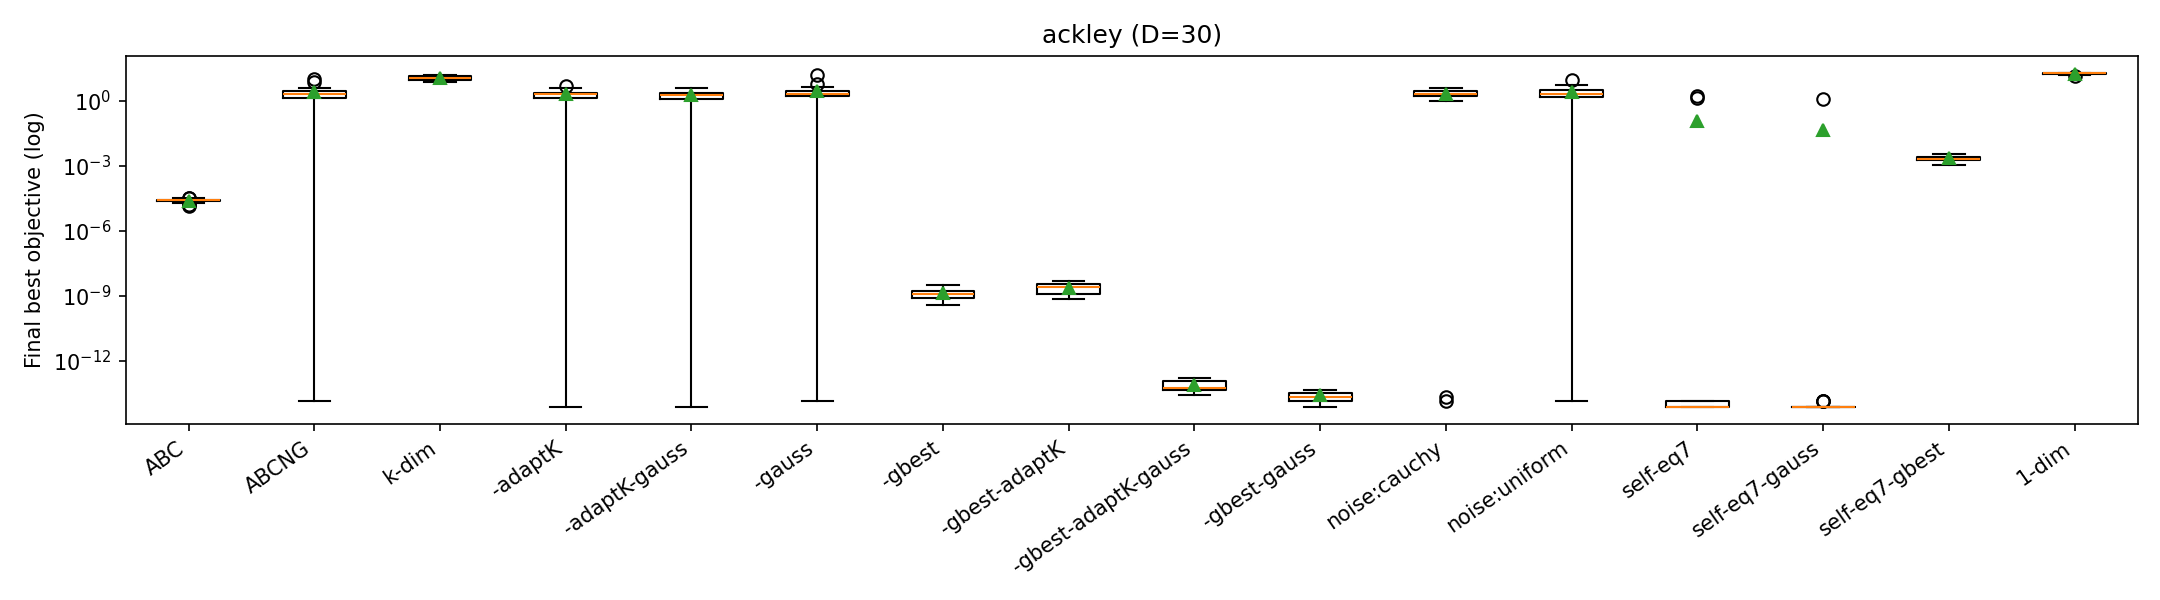

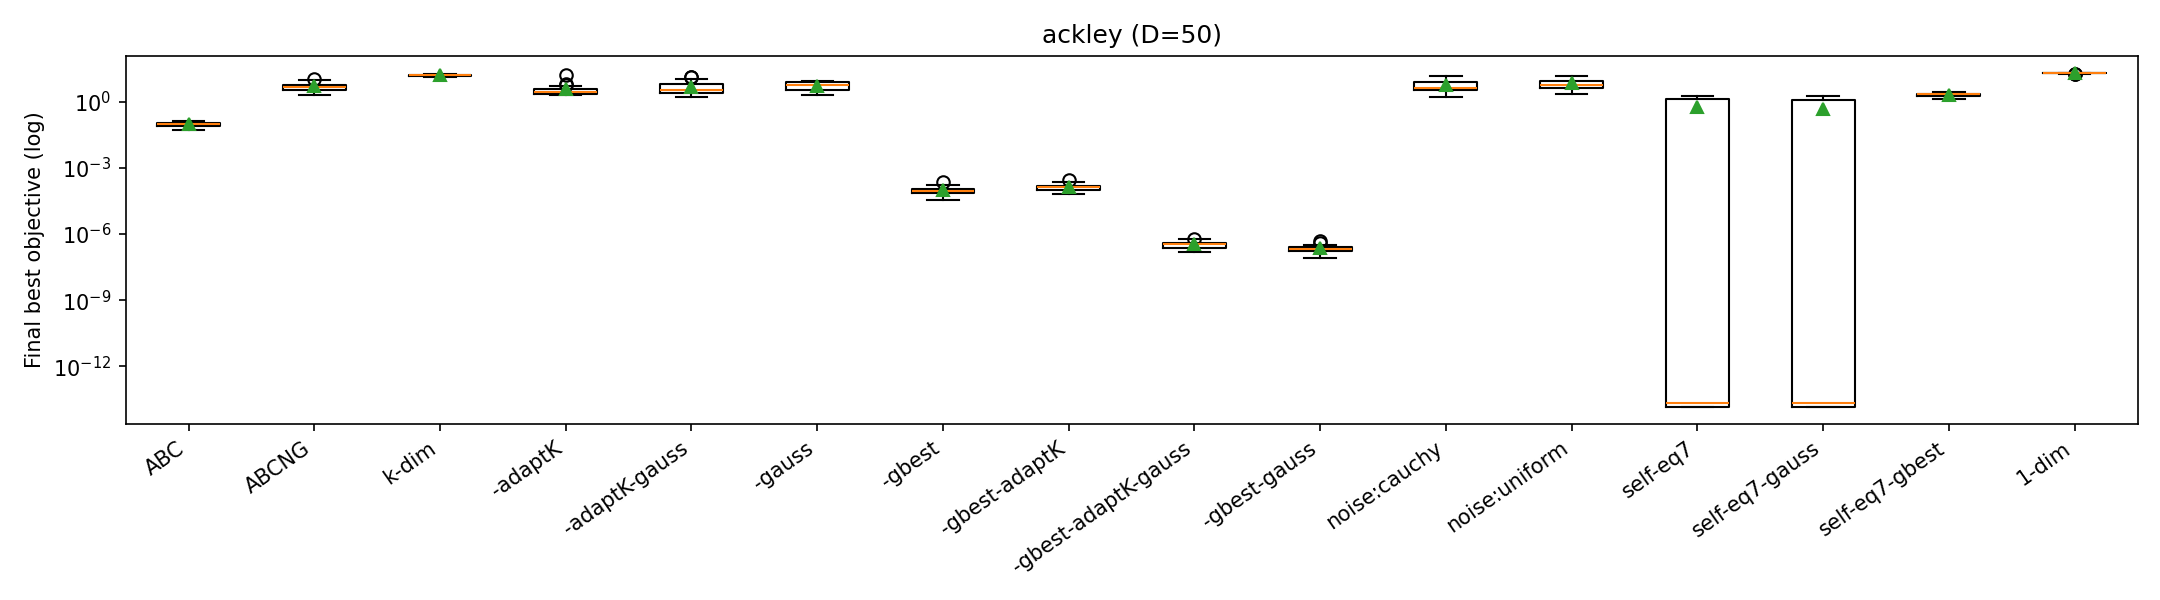

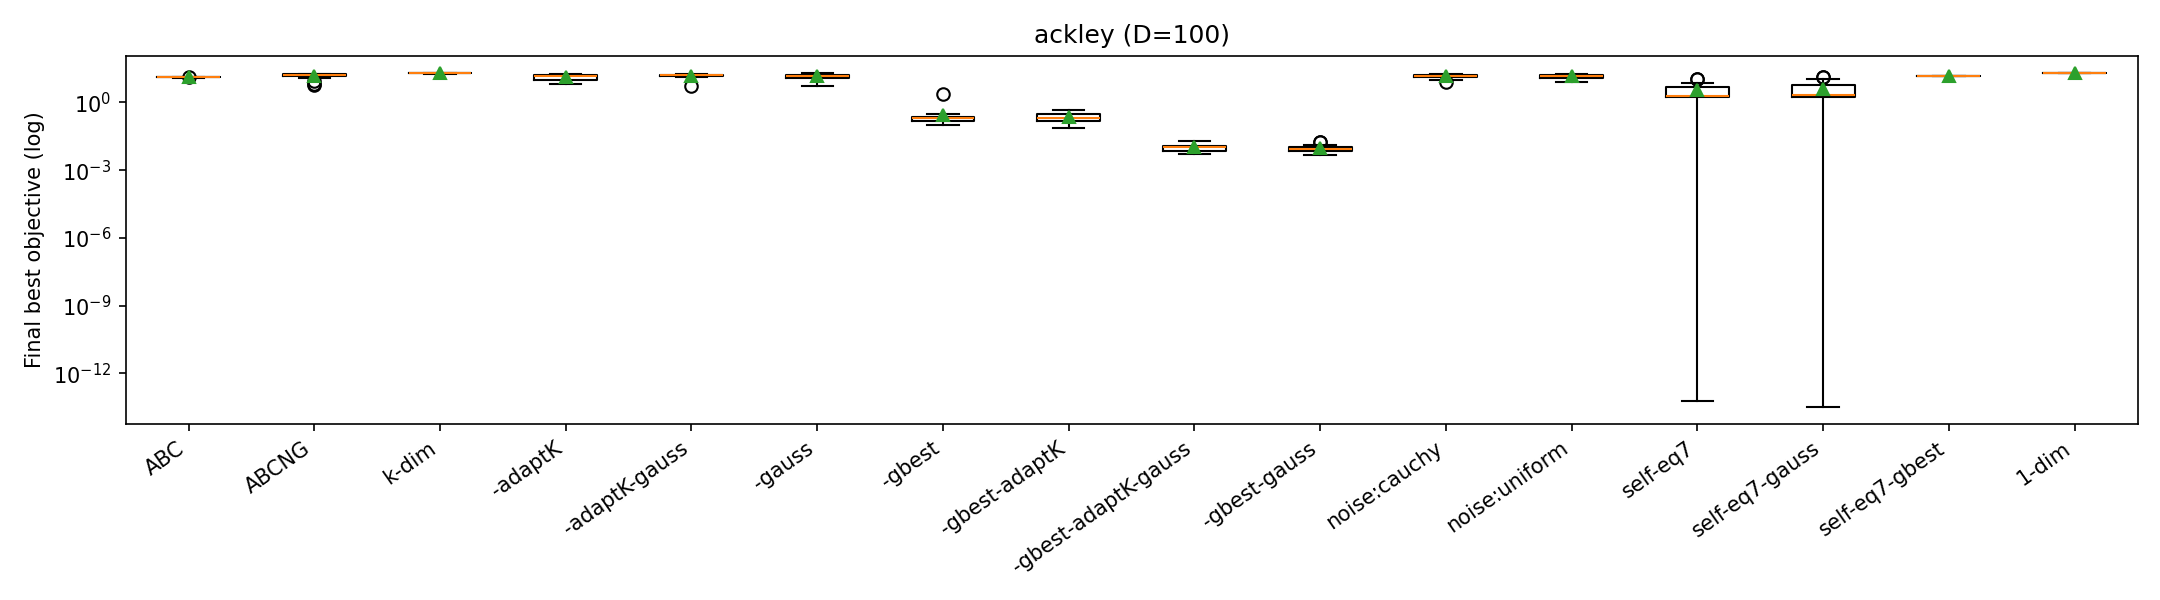

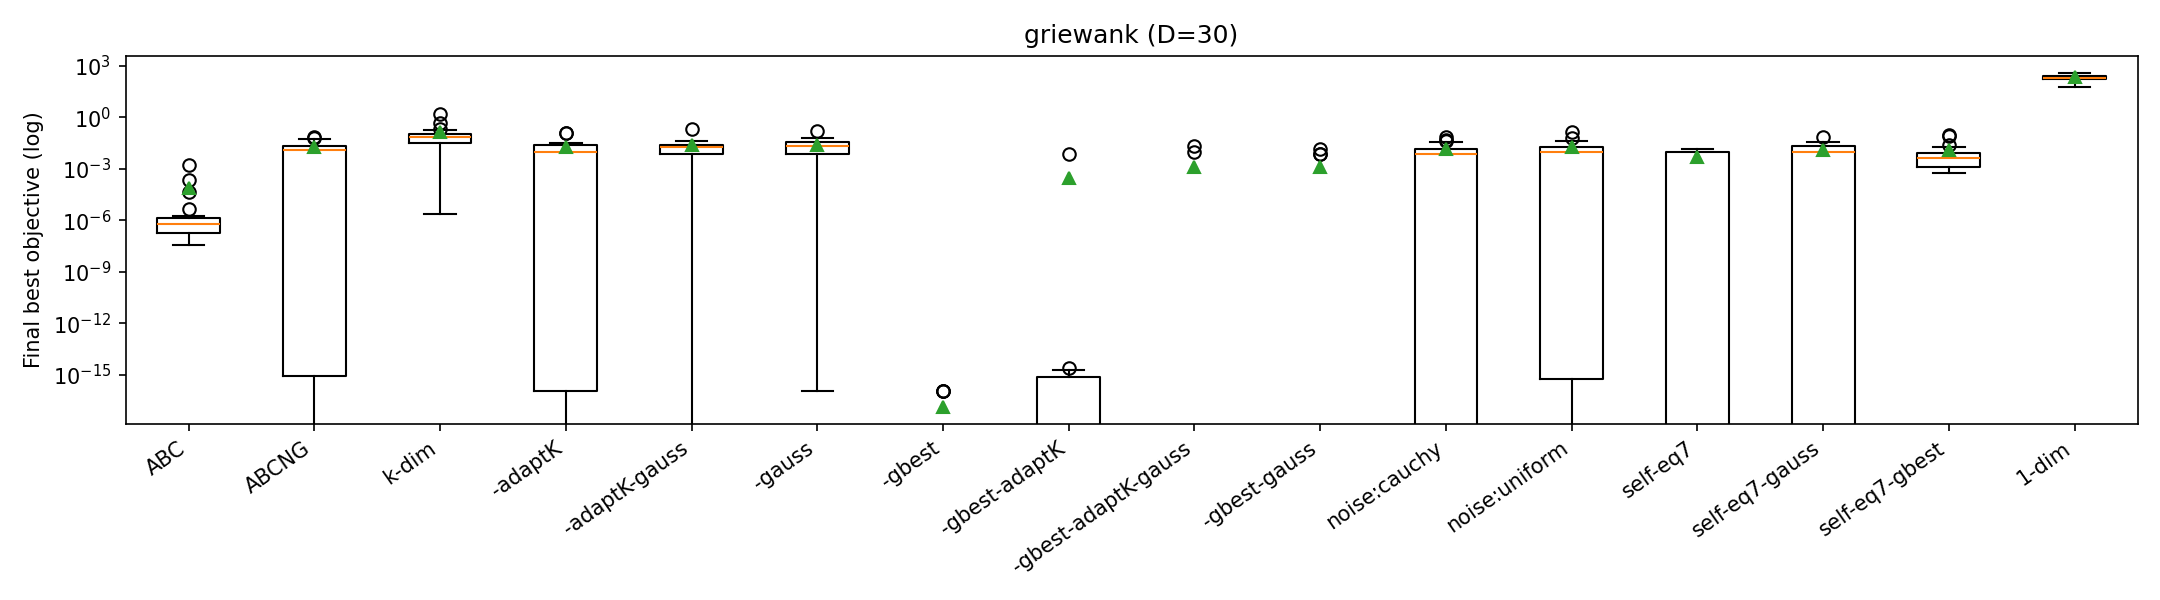

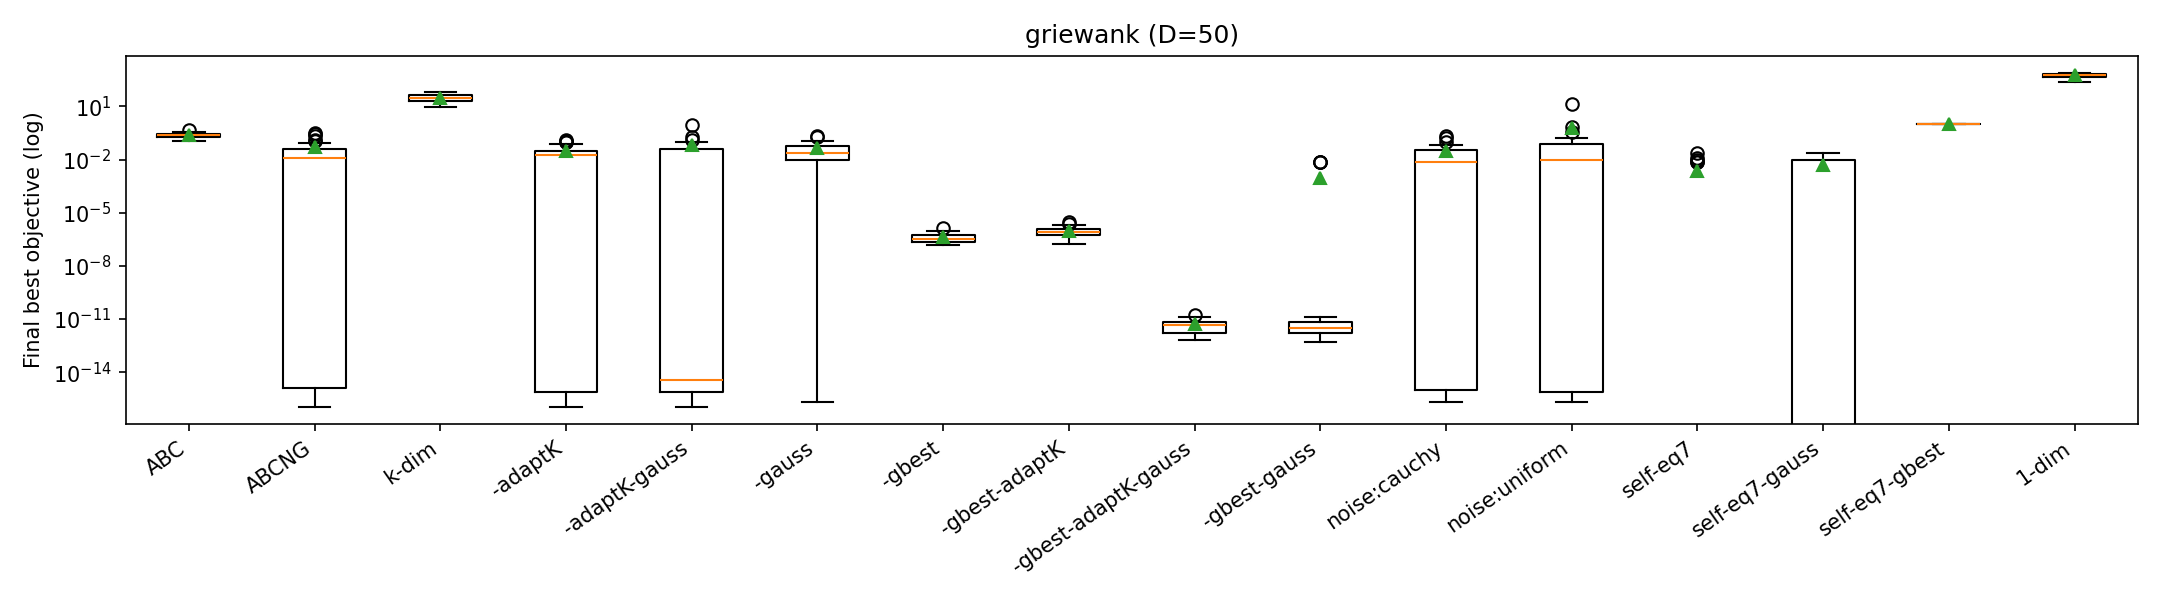

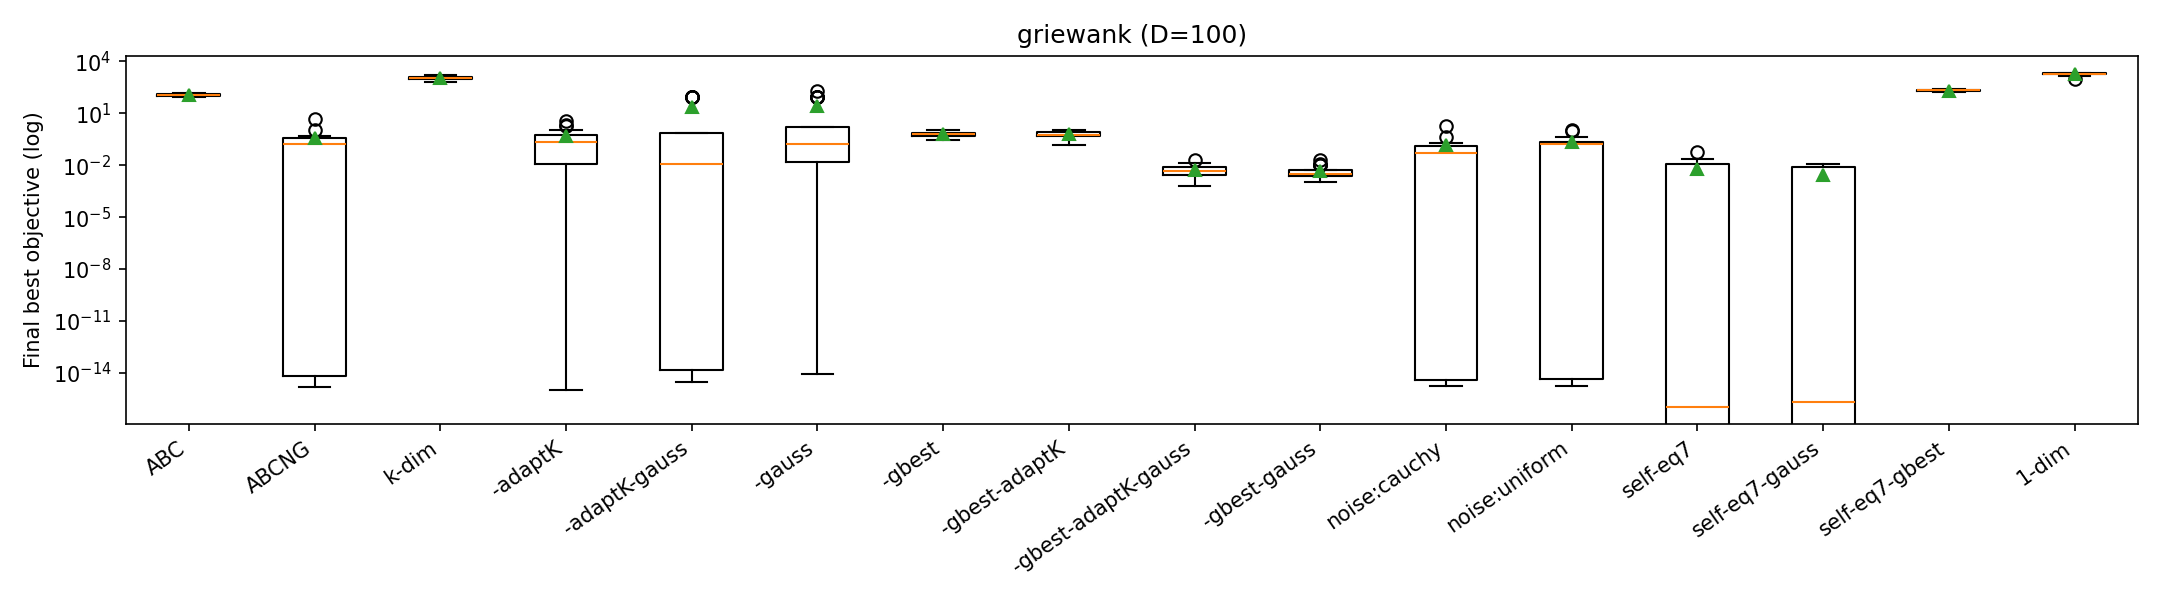

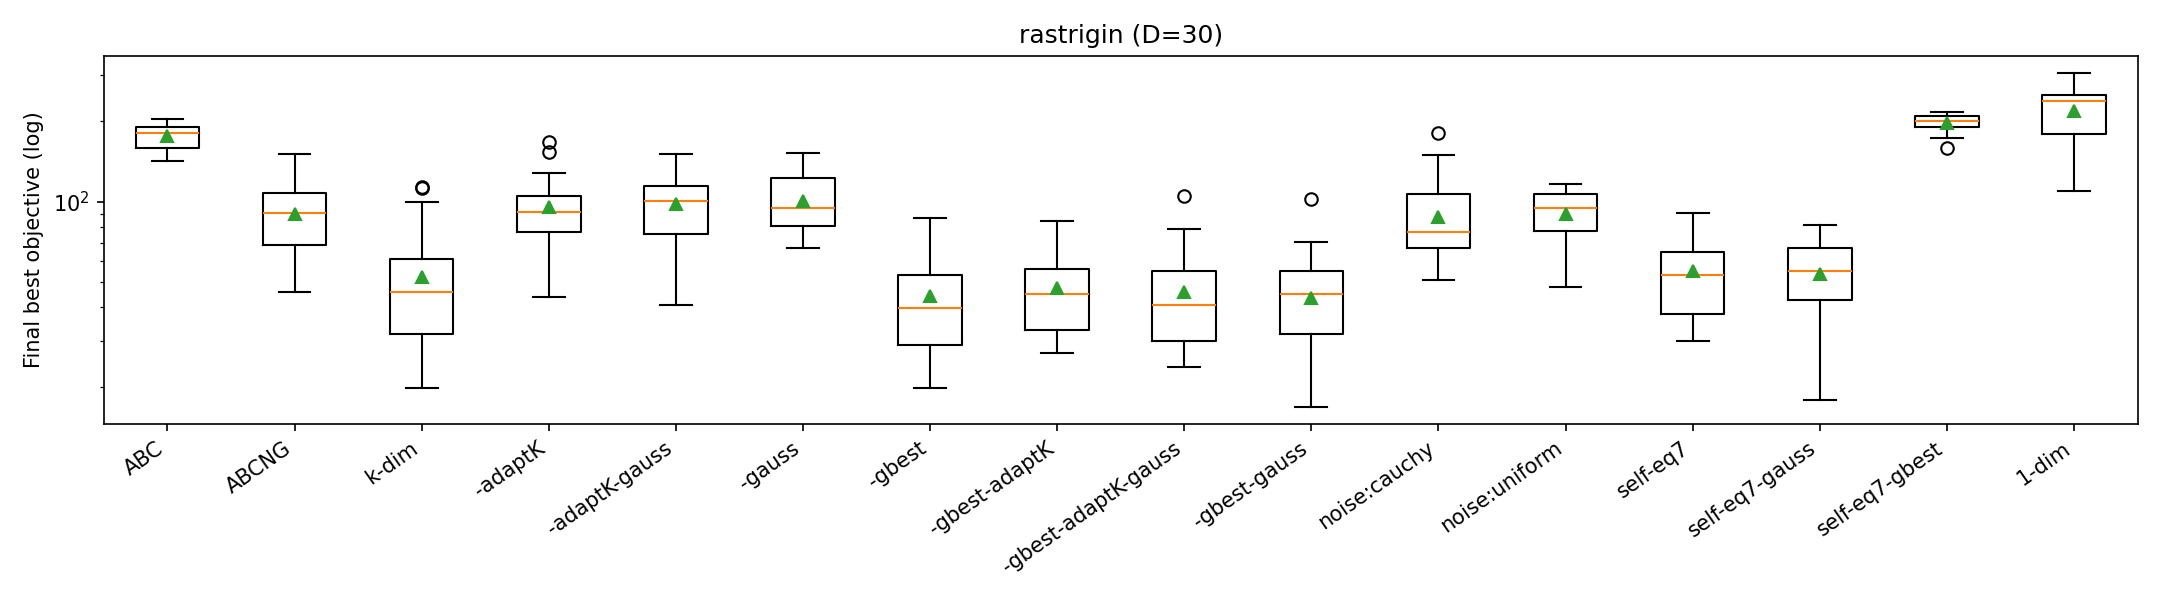

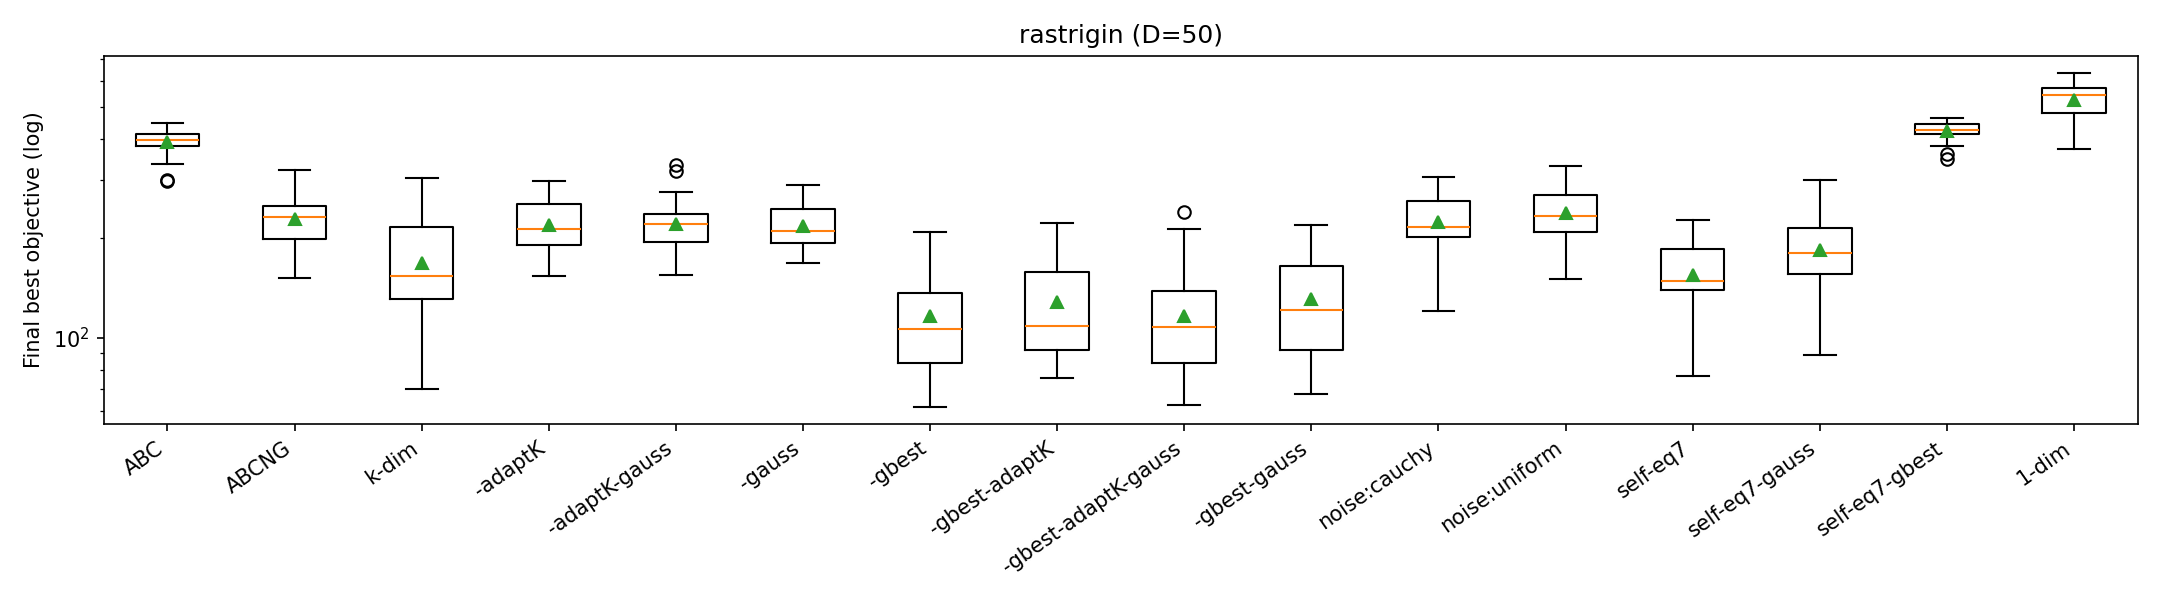

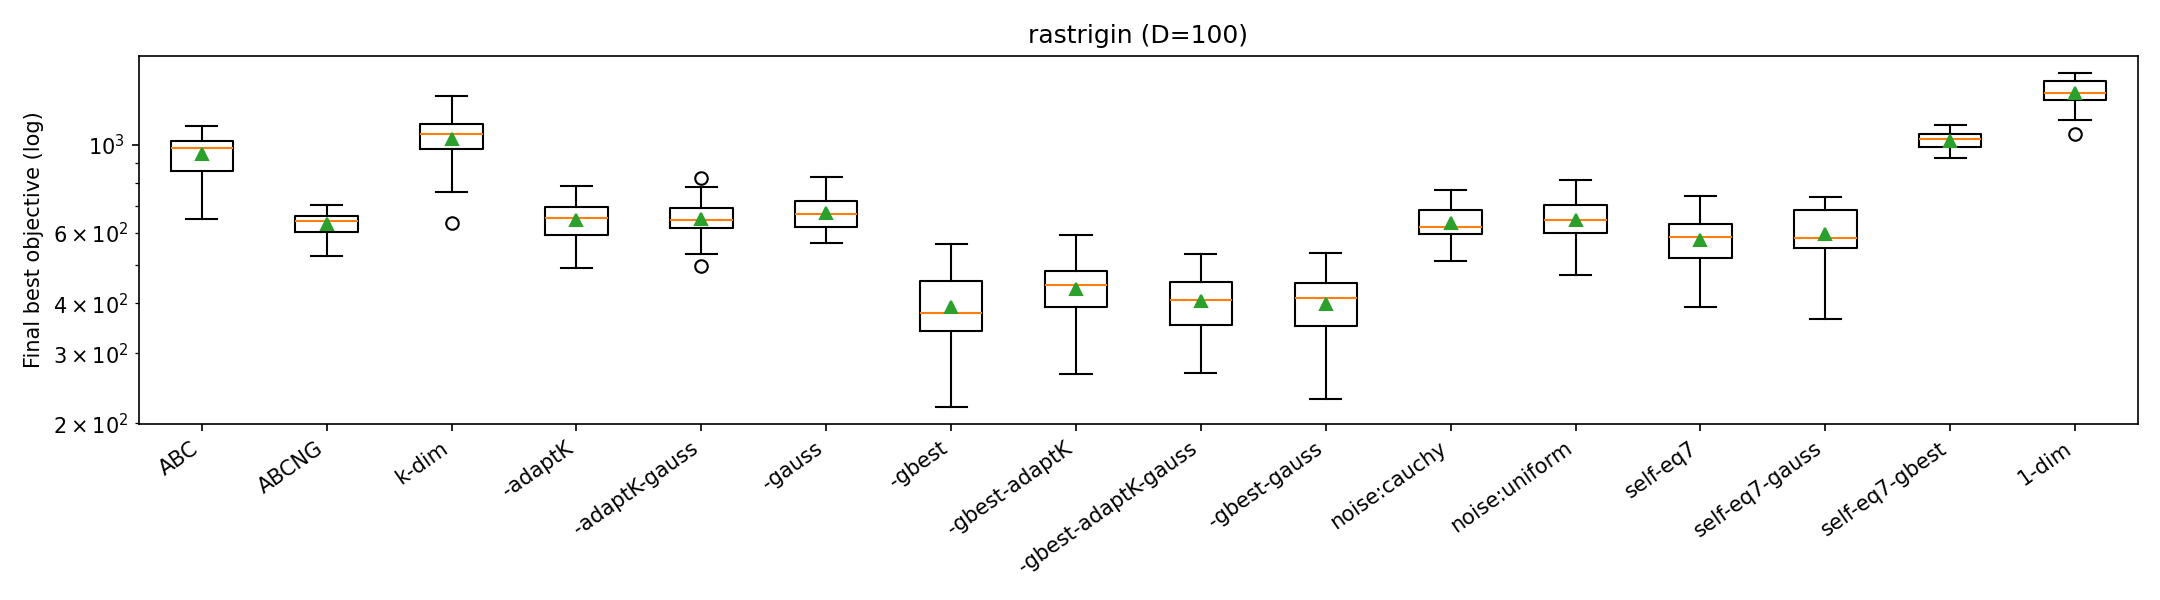

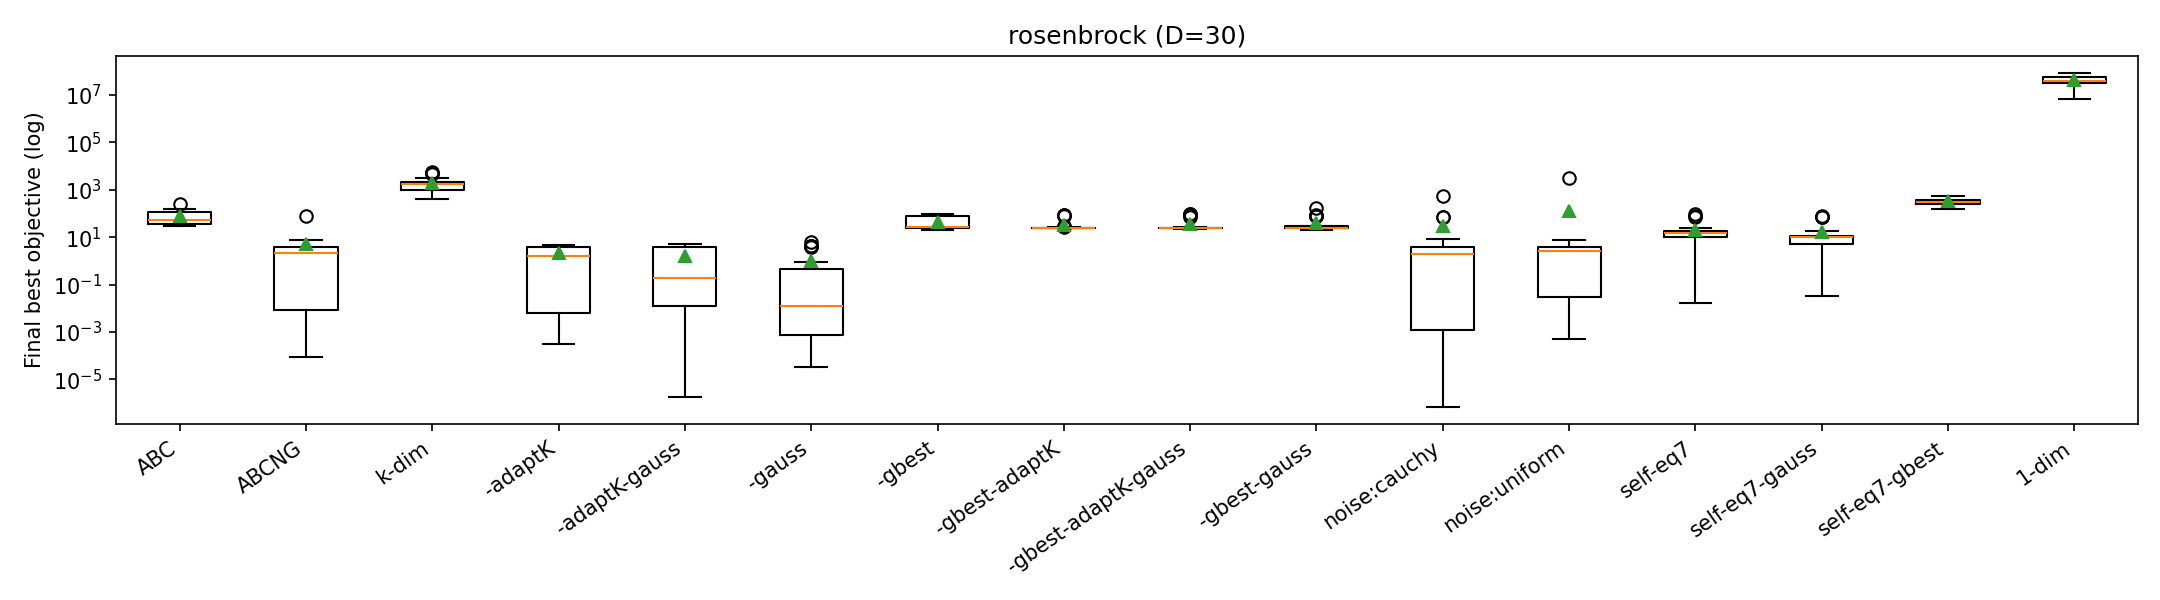

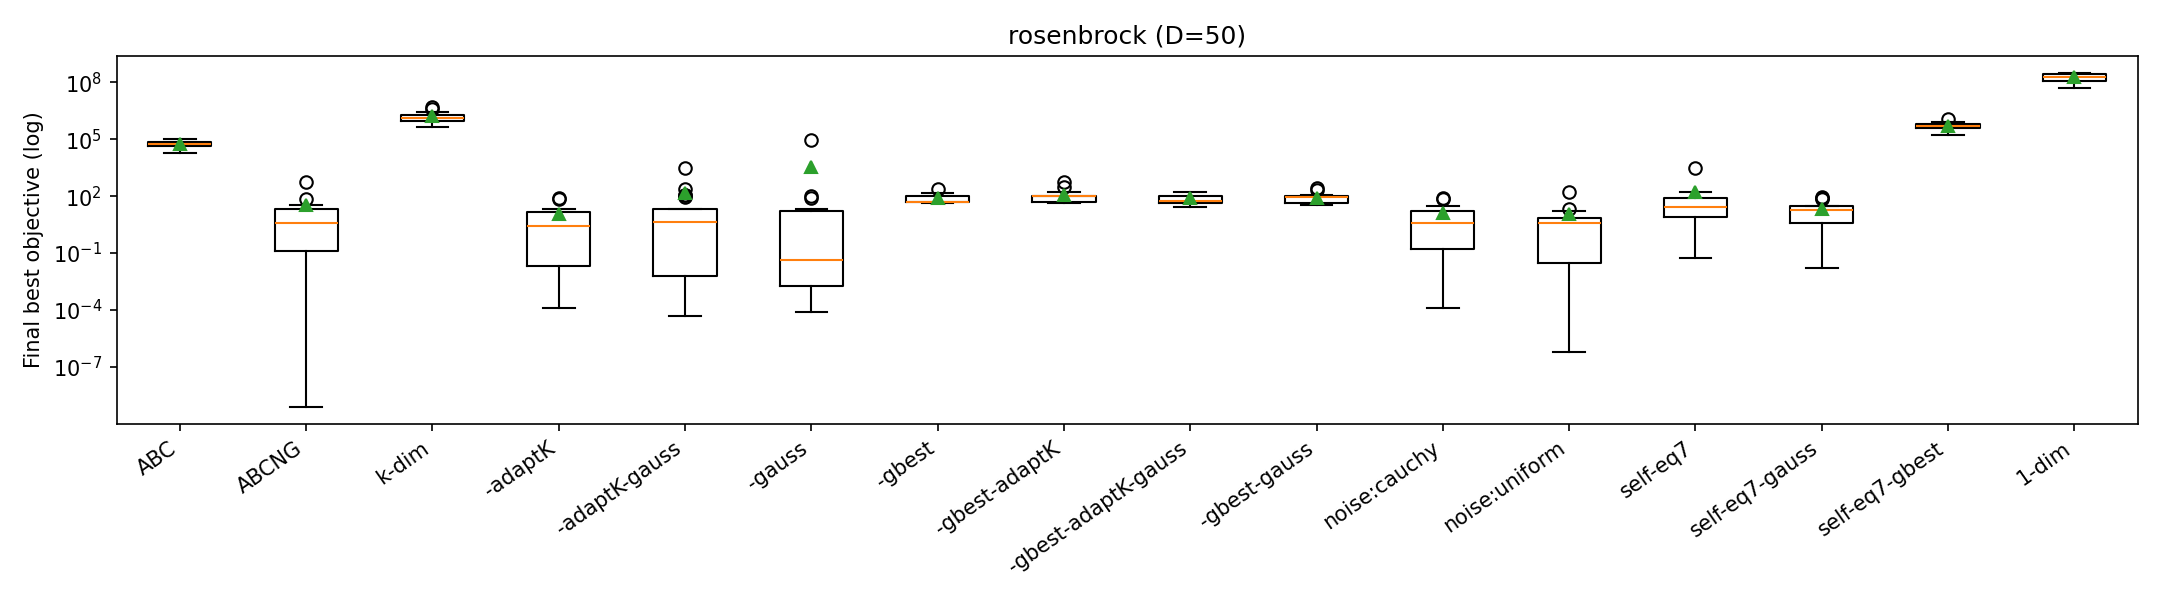

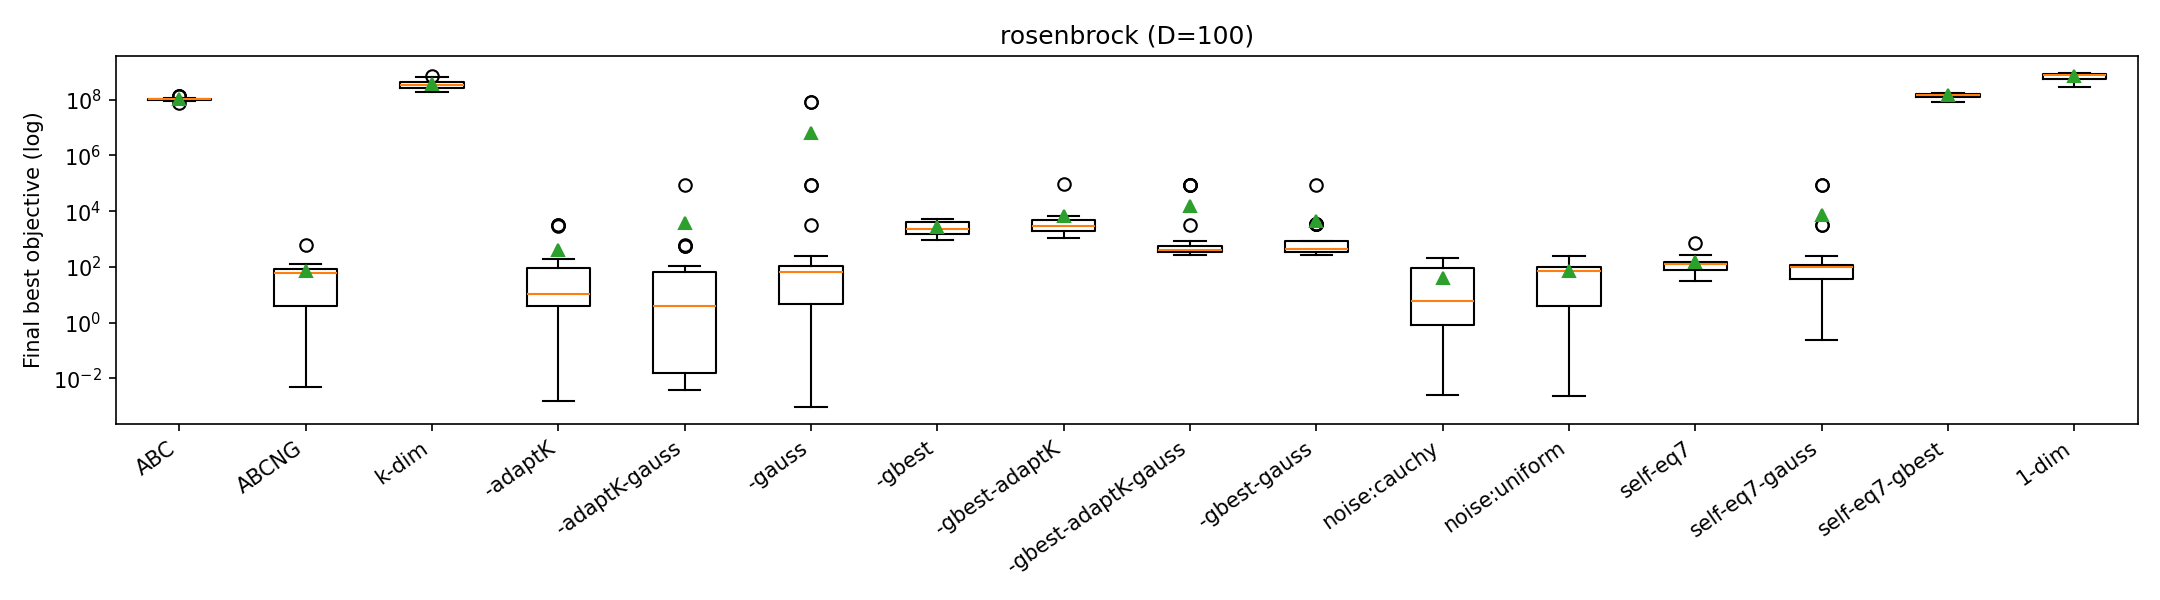

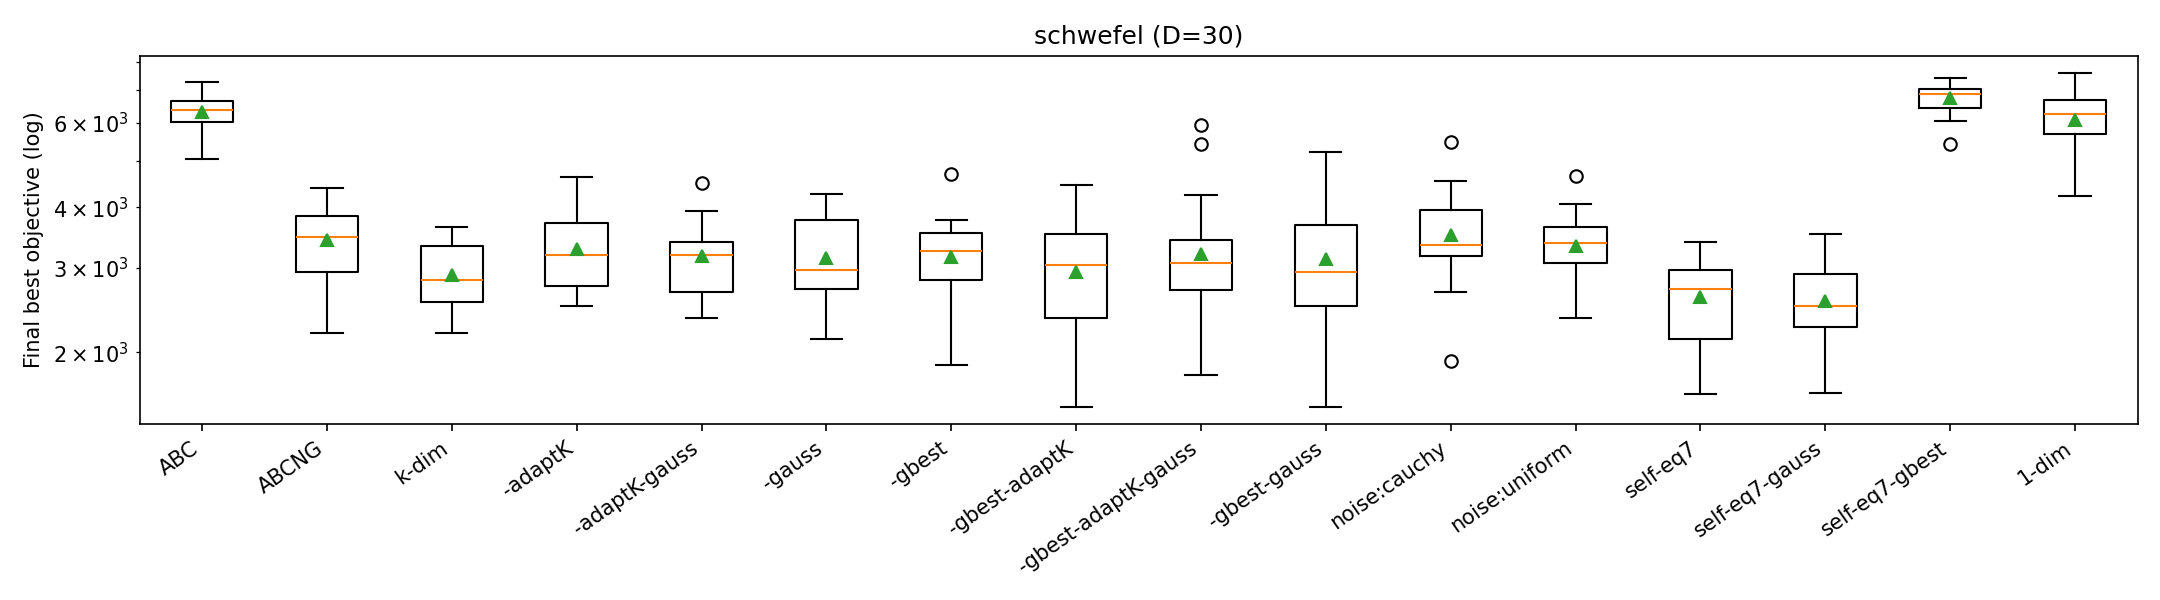

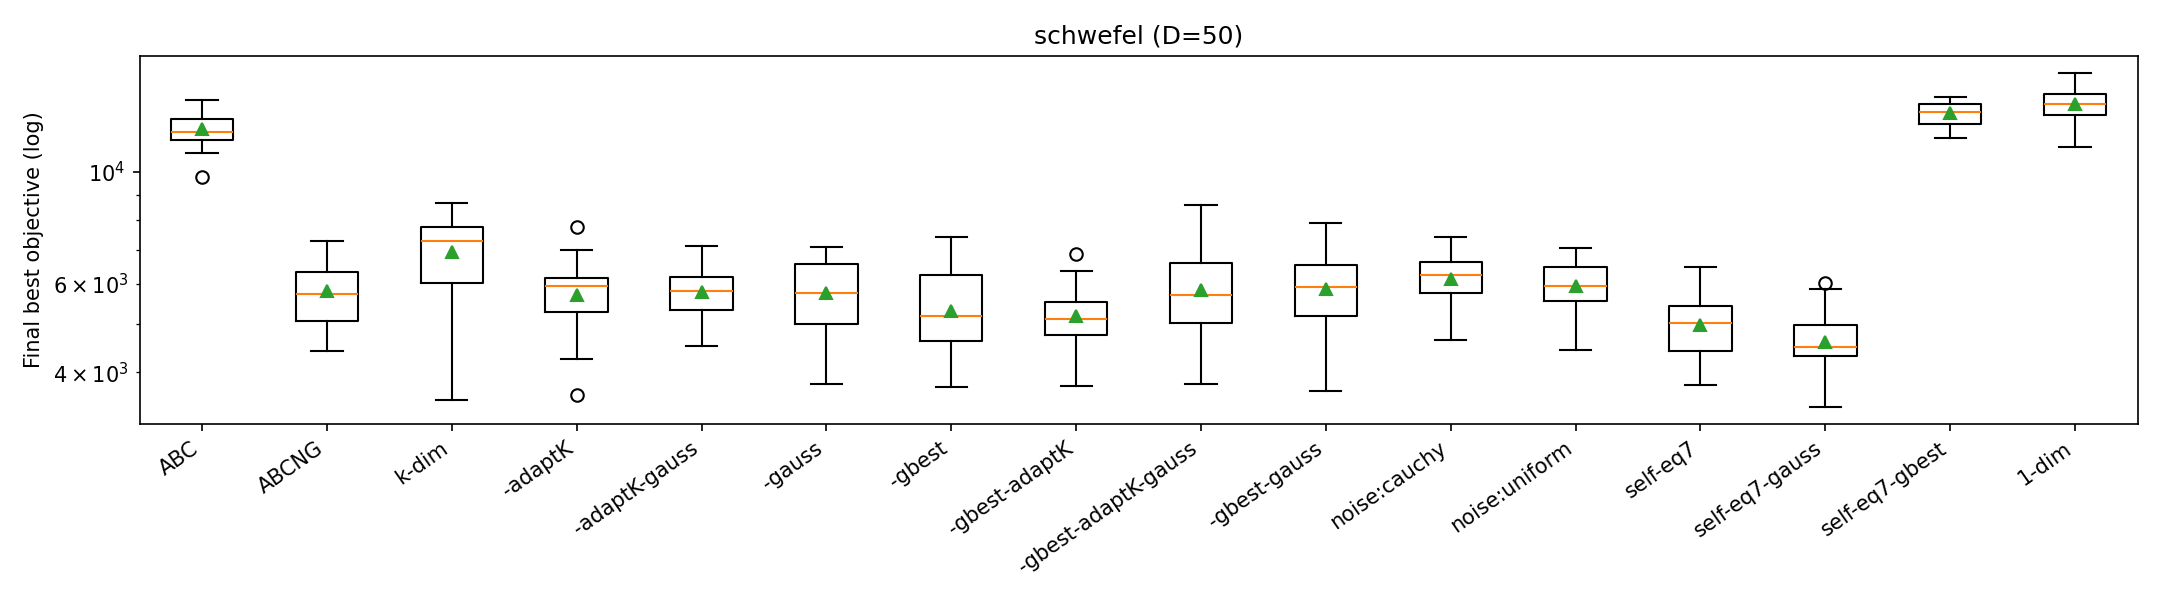

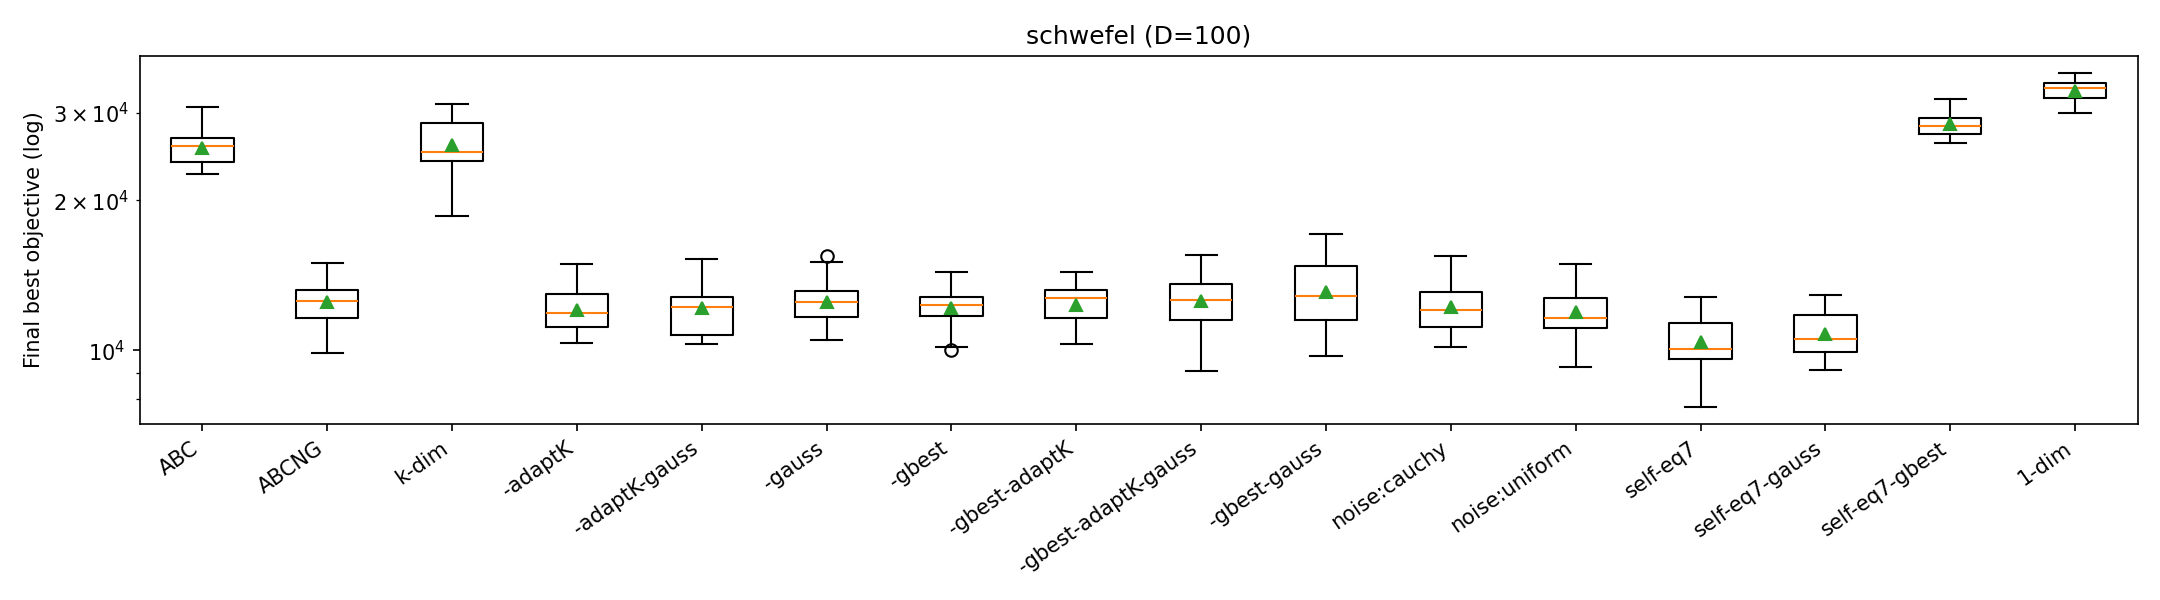

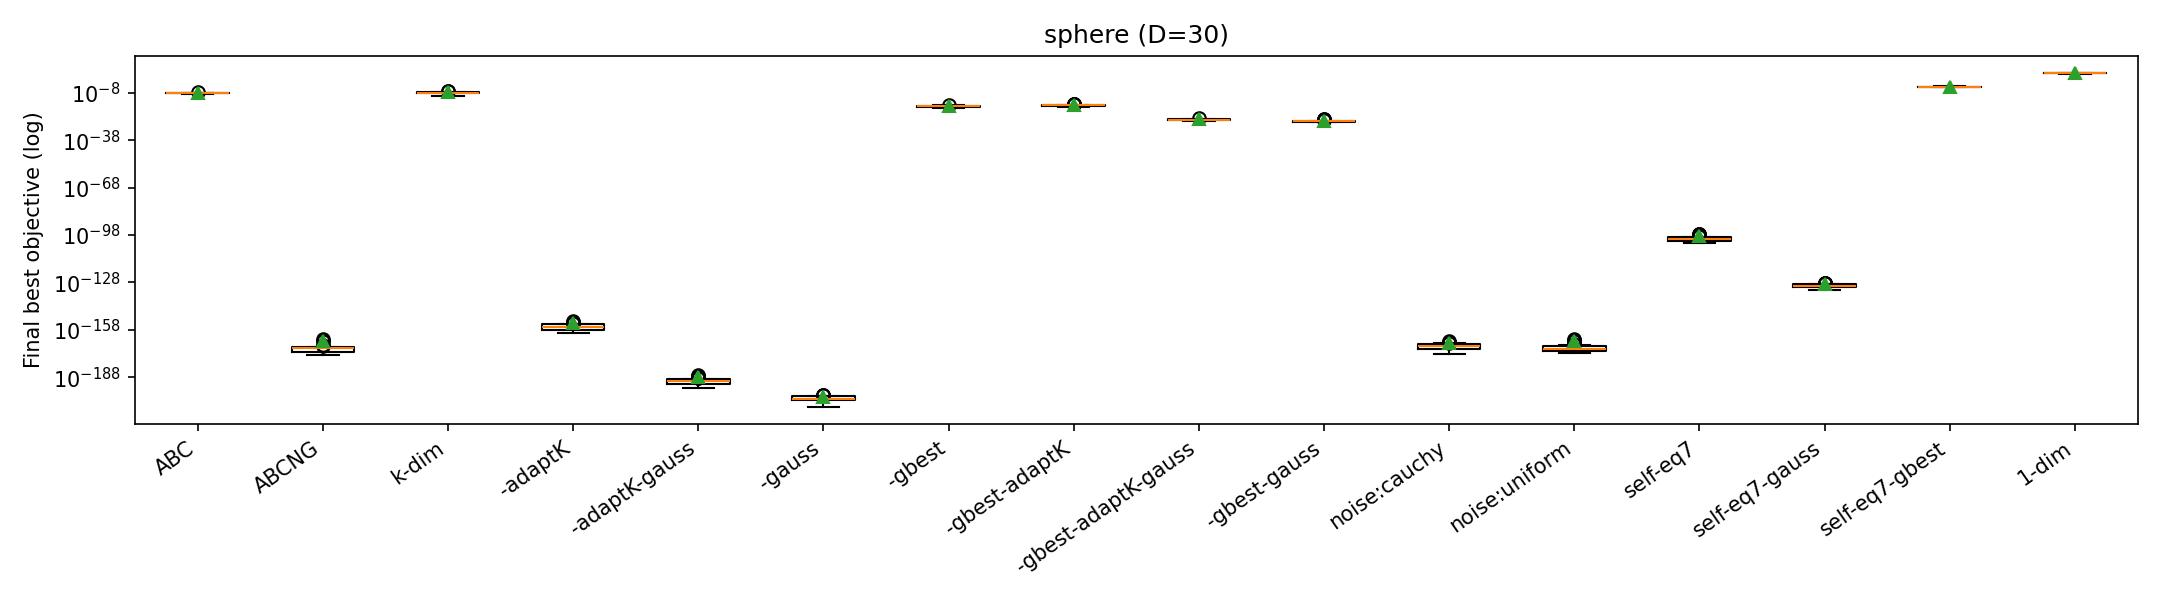

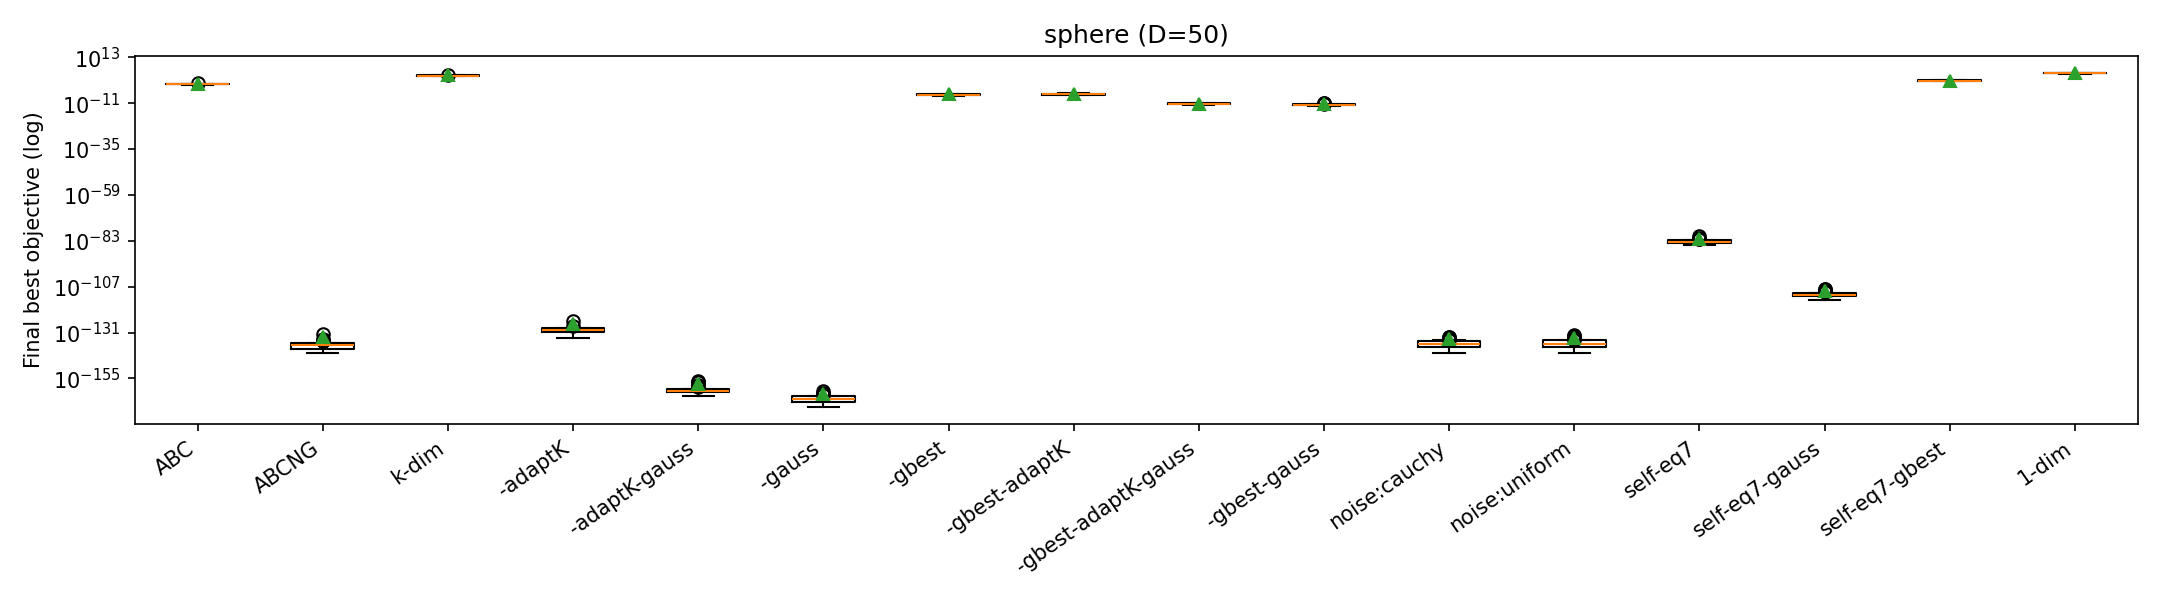

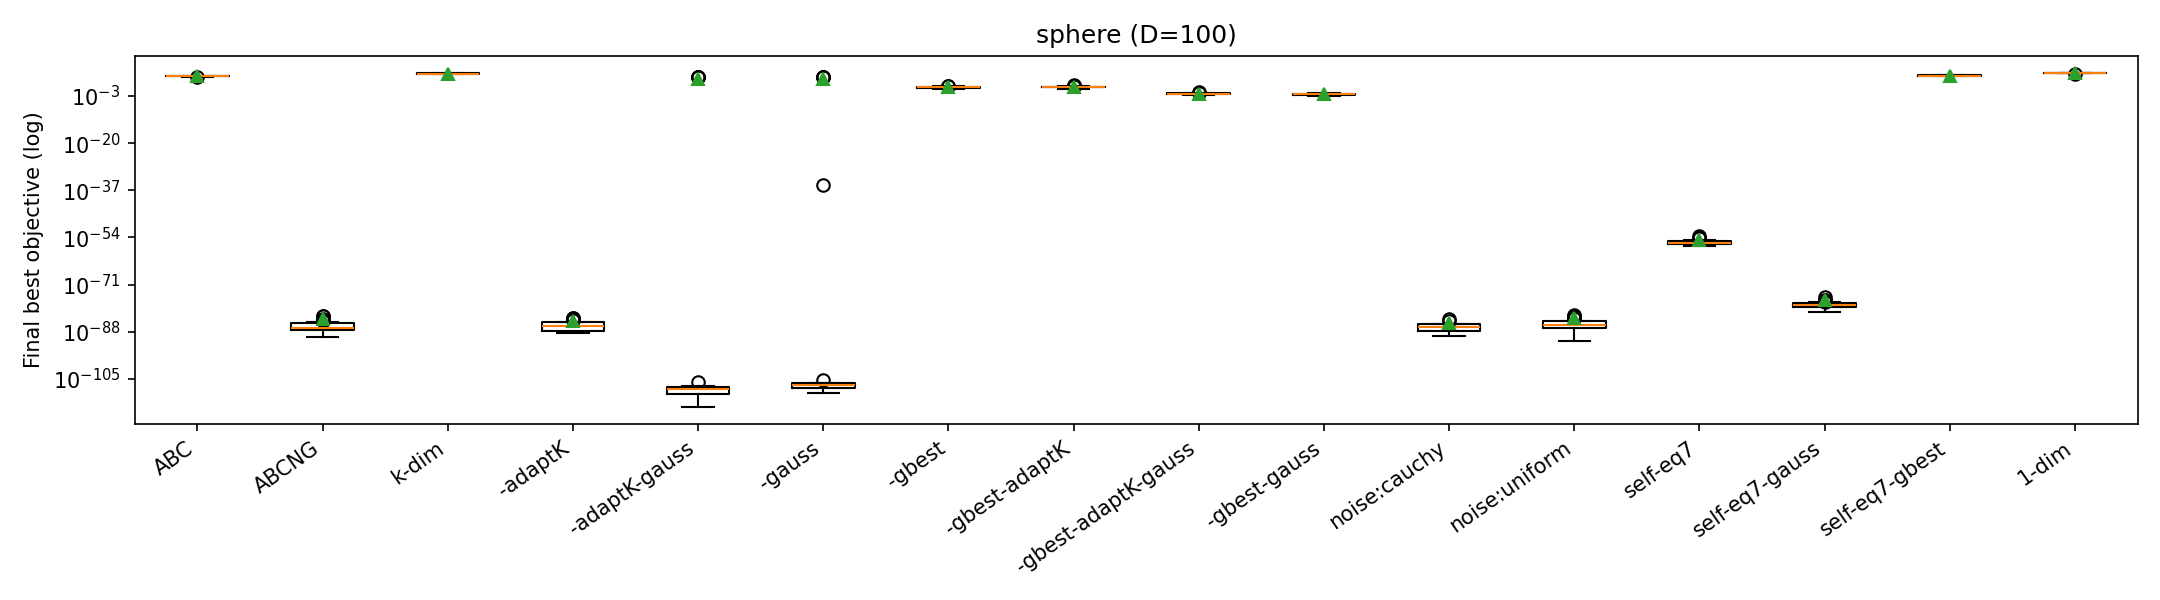

In [4]:
# Comparison plots across variants (boxplots per function/dim)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

compare_dir = os.path.join(base_out, "compare")
os.makedirs(compare_dir, exist_ok=True)

label_map = {
    "abc": "ABC",
    "abcng_full": "ABCNG",
    "no_gbest": "-gbest",
    "no_adaptive_k": "-adaptK",
    "no_gaussian": "-gauss",
    "self_in_eq7": "self-eq7",
    "single_dim_update": "1-dim",
    "k_random_dim_update": "k-dim",
    "noise_cauchy": "noise:cauchy",
    "noise_uniform": "noise:uniform",
    "no_gbest_no_adaptive_k": "-gbest-adaptK",
    "no_gbest_no_gaussian": "-gbest-gauss",
    "no_adaptive_k_no_gaussian": "-adaptK-gauss",
    "no_gbest_no_adaptive_k_no_gaussian": "-gbest-adaptK-gauss",
    "self_in_eq7_no_gbest": "self-eq7-gbest",
    "self_in_eq7_no_gaussian": "self-eq7-gauss",
}

frames = []
for name, _, _ in variants:
    runs_path = os.path.join(base_out, name, "runs.csv")
    if not os.path.exists(runs_path):
        print(f"Missing runs.csv for {name}: {runs_path}")
        continue
    df = pd.read_csv(runs_path)
    df["variant"] = name
    frames.append(df)

all_runs = pd.concat(frames, ignore_index=True)

# Aggregate summary table
summary = (
    all_runs.groupby(["function", "dim", "variant"])["final_best"]
    .agg(["median", "mean", "std"])
    .reset_index()
)
summary_path = os.path.join(compare_dir, "summary_compare.csv")
summary.to_csv(summary_path, index=False)
print("Saved", summary_path)

# Boxplots per function/dim across variants
plot_paths = []
for (fn, d), group in all_runs.groupby(["function", "dim"]):
    labels = []
    data = []
    for vname, vgroup in group.groupby("variant"):
        labels.append(label_map.get(vname, vname))
        data.append(vgroup["final_best"].values)

    plt.figure(figsize=(max(8, len(labels) * 0.9), 4))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.yscale("log")
    plt.ylabel("Final best objective (log)")
    plt.title(f"{fn} (D={d})")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    out = os.path.join(compare_dir, f"box_{fn}_D{d}.png")
    plt.savefig(out, dpi=150)
    plt.close()
    plot_paths.append(out)
    print("Saved", out)

# Display plots inline
for p in plot_paths:
    display(Image(filename=p))


## Summary for Presentation


In [5]:
# Summary stats: median across functions/dims and win/tie/loss vs ABCNG
import os
import pandas as pd
import numpy as np

summary_path = os.path.join(base_out, "compare", "summary_compare.csv")
if not os.path.exists(summary_path):
    raise FileNotFoundError(summary_path)
summary = pd.read_csv(summary_path)

# Median final score per variant (aggregate over all functions/dims)
variant_medians = (
    summary.groupby("variant")["median"]
    .median()
    .sort_values()
)
display(variant_medians.to_frame("median_final_across_all"))

# Win/Tie/Loss vs ABCNG baseline (lower is better)
baseline = "abcng_full"
pivot = summary.pivot_table(index=["function", "dim"], columns="variant", values="median")
if baseline not in pivot.columns:
    raise ValueError(f"Baseline {baseline} not found in summary_compare.csv")

def wtl(col):
    b = pivot[baseline]
    v = pivot[col]
    win = int((v < b).sum())
    tie = int((v == b).sum())
    loss = int((v > b).sum())
    return pd.Series({"win": win, "tie": tie, "loss": loss})

wtl_table = pivot.columns.to_series().apply(wtl)
display(wtl_table.sort_values(["win", "loss"], ascending=[False, True]))


,median_final_across_all
variant,
no_adaptive_k,2.723082
no_adaptive_k_no_gaussian,3.663142
no_gaussian,3.796452
noise_cauchy,4.184052
abcng_full,4.244234
noise_uniform,4.770978
self_in_eq7_no_gaussian,6.235906
self_in_eq7,8.823515
no_gbest_no_gaussian,11.985371


,win,tie,loss
variant,,,
no_adaptive_k_no_gaussian,12,0,6
noise_cauchy,12,0,6
self_in_eq7,12,0,6
self_in_eq7_no_gaussian,12,0,6
no_gbest,11,0,7
no_gbest_no_adaptive_k_no_gaussian,11,0,7
no_adaptive_k,10,0,8
no_gbest_no_adaptive_k,10,0,8
no_gbest_no_gaussian,10,0,8
